In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as ss
import pickle
import os
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from rdkit.Chem import Draw
from collections import Counter

plt.rcParams['figure.dpi'] = 300

In [2]:
# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/scripts'
PATH_TO_DOCKING_RESULTS_ORIGINAL = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')
PATH_TO_DOCKING_RESULTS_REAL = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'docking_results')
PATH_TO_INPUT_LIGANDS = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'input_ligands')

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

In [3]:
DOCKING_RESULTS_ORIGINAL = {}
DOCKING_RESULTS_REAL = {}
DOCKING_RESULTS_REAL_BACKGROUND = {}

# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_ORIGINAL))):
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_ORIGINAL, pocket, 'report.csv'))
    DOCKING_RESULTS_ORIGINAL[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL))):
    # try:
    lines = open(os.path.join(PATH_TO_INPUT_LIGANDS, f"input_ligands_{pocket}.txt"), "r").readlines()
    lines = [i.strip().replace(".sdf", "").split("/")[-1] for i in lines]
    actives = set(lines[:100000])
    inactives = set(lines[100000:])
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL, pocket, 'report.csv'))
    scores['set'] = ["inactive" if i in inactives else "active" for i in scores['compound']]
    scores_actives = scores[scores['set'] == 'active'].reset_index(drop=True)
    scores_inactives = scores[scores['set'] == 'inactive'].reset_index(drop=True)
    DOCKING_RESULTS_REAL[pocket] = {i: j for i, j in zip(scores_actives['compound'], scores_actives['score'])}
    DOCKING_RESULTS_REAL_BACKGROUND[pocket] = {i: j for i, j in zip(scores_inactives['compound'], scores_inactives['score'])}
    # except:
    #     pass

100%|██████████| 276/276 [00:32<00:00,  8.61it/s]


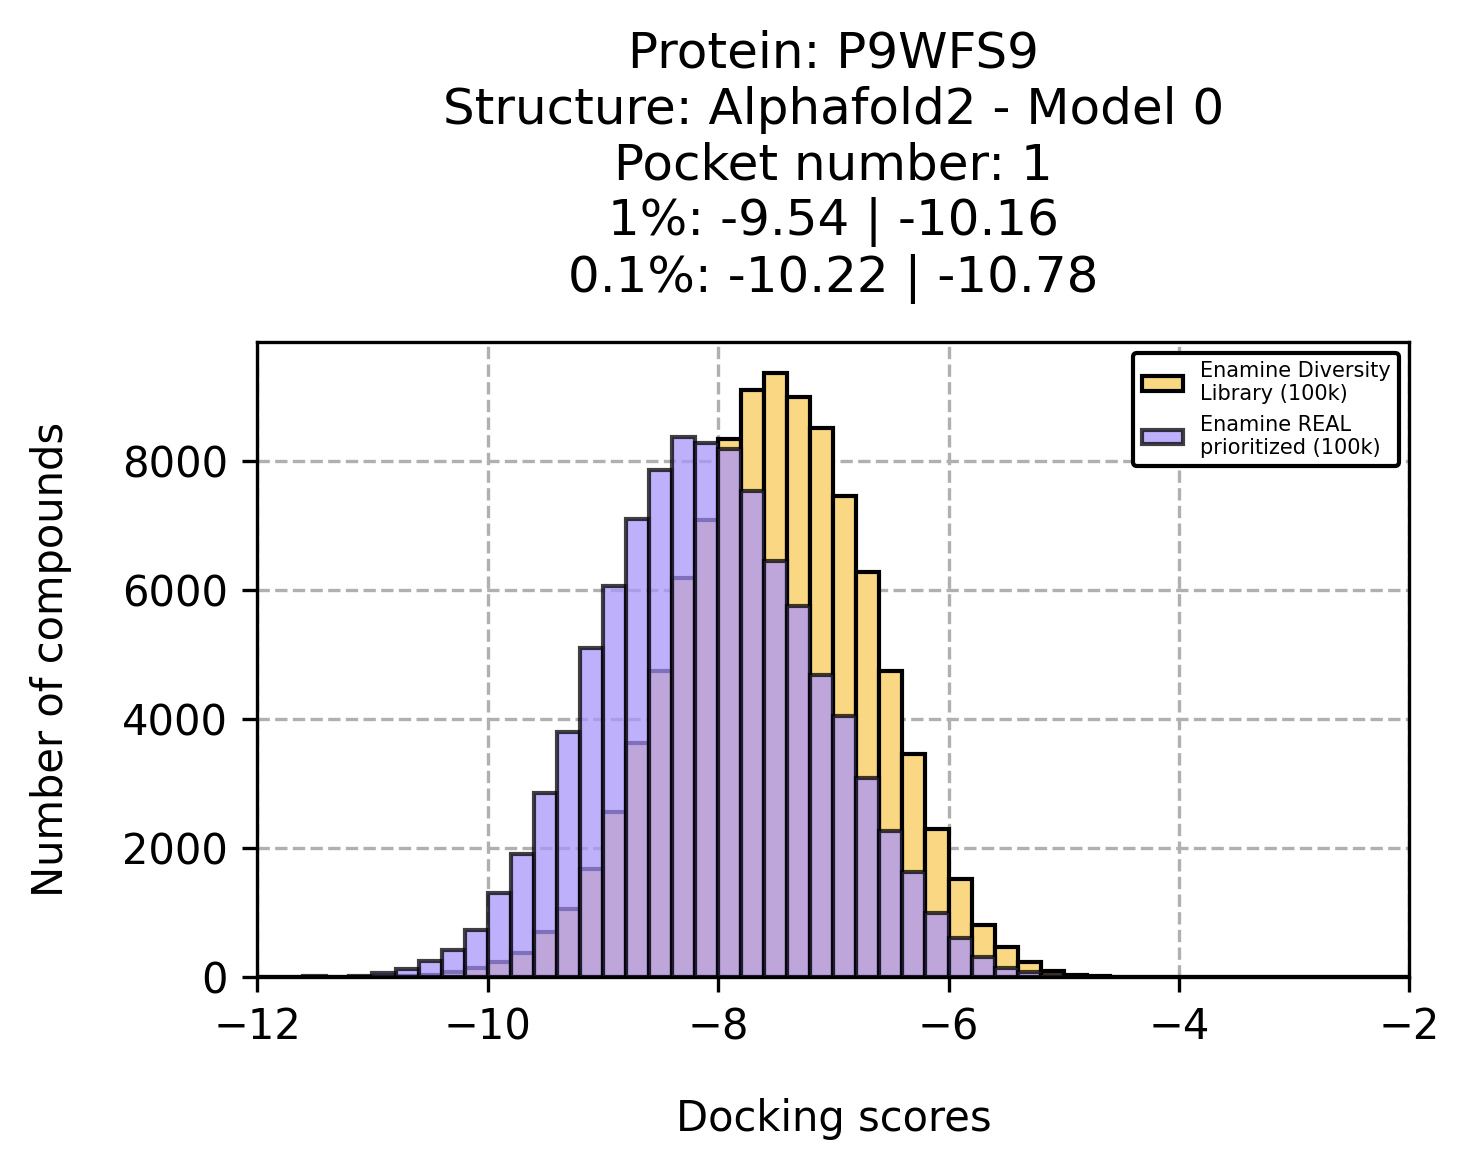

In [4]:
pocket = 'alphafold2_P9WFT3_model_0_pocket_2'
pocket = "alphafold2_P9WFS9_model_0_pocket_1"
bins = [i for i in np.arange(-14, 1, 0.2)]

y1 = list(DOCKING_RESULTS_ORIGINAL[pocket].values())
y2 = list(DOCKING_RESULTS_REAL[pocket].values())
p = f"Protein: {pocket.split('_')[1]}\nStructure: {pocket.split('_')[0].capitalize()} - Model {pocket.split('_')[3]}\nPocket number: {pocket.split('_')[-1]}"
title = f"{p}\n1%: {round(np.percentile(y1, 1), 2)} | {round(np.percentile(y2, 1), 2)}\n0.1%: {round(np.percentile(y1, 0.1), 2)} | {round(np.percentile(y2, 0.1), 2)}"



plt.figure(figsize=(5, 4))
plt.hist(y1, bins=bins, zorder=2, edgecolor='k', color="#FAD782", label='Enamine Diversity\nLibrary (100k)')
plt.hist(y2, bins=bins, zorder=2, edgecolor='k', color="#AA96FA", label='Enamine REAL\nprioritized (100k)', alpha=0.75)
plt.grid(linestyle='--', zorder=-2)
plt.xlim([-12, -2])
plt.xlabel("Docking scores", labelpad=12)
plt.ylabel("Number of compounds", labelpad=12)
plt.legend(loc='best', framealpha=1, edgecolor='k', prop={'size': 5})
plt.title(title, pad=12)
plt.tight_layout()
plt.show()

In [5]:
### BOXPLOTS ###

In [6]:
def simple_boxplot(ax, x, y, c, width):
    ax.boxplot(y, positions=[x], widths=width, patch_artist=True, whis=[1, 99], showfliers=False,
               boxprops=dict(facecolor=c, color='black', lw=0.25),
               medianprops=dict(color='black', lw=0.25),
               whiskerprops=dict(color='black', lw=0.25),
               capprops=dict(color='none', lw=0.25))
    
def simple_boxplot_label(ax, x, y, c, width, label):
    lw = 0.35
    ax.boxplot(y, positions=[x], widths=width, patch_artist=True, whis=[1, 99], showfliers=False, label=label,
               boxprops=dict(facecolor=c, color='black', lw=lw),
               medianprops=dict(color='black', lw=lw),
               whiskerprops=dict(color='black', lw=lw),
               capprops=dict(color='none', lw=lw))

In [7]:
ind = np.argsort([np.median(list(DOCKING_RESULTS_ORIGINAL[x].values())) for x in sorted(DOCKING_RESULTS_ORIGINAL)])
ind_100 = np.argsort([sorted(DOCKING_RESULTS_ORIGINAL[x].values())[99] for x in sorted(DOCKING_RESULTS_ORIGINAL)])

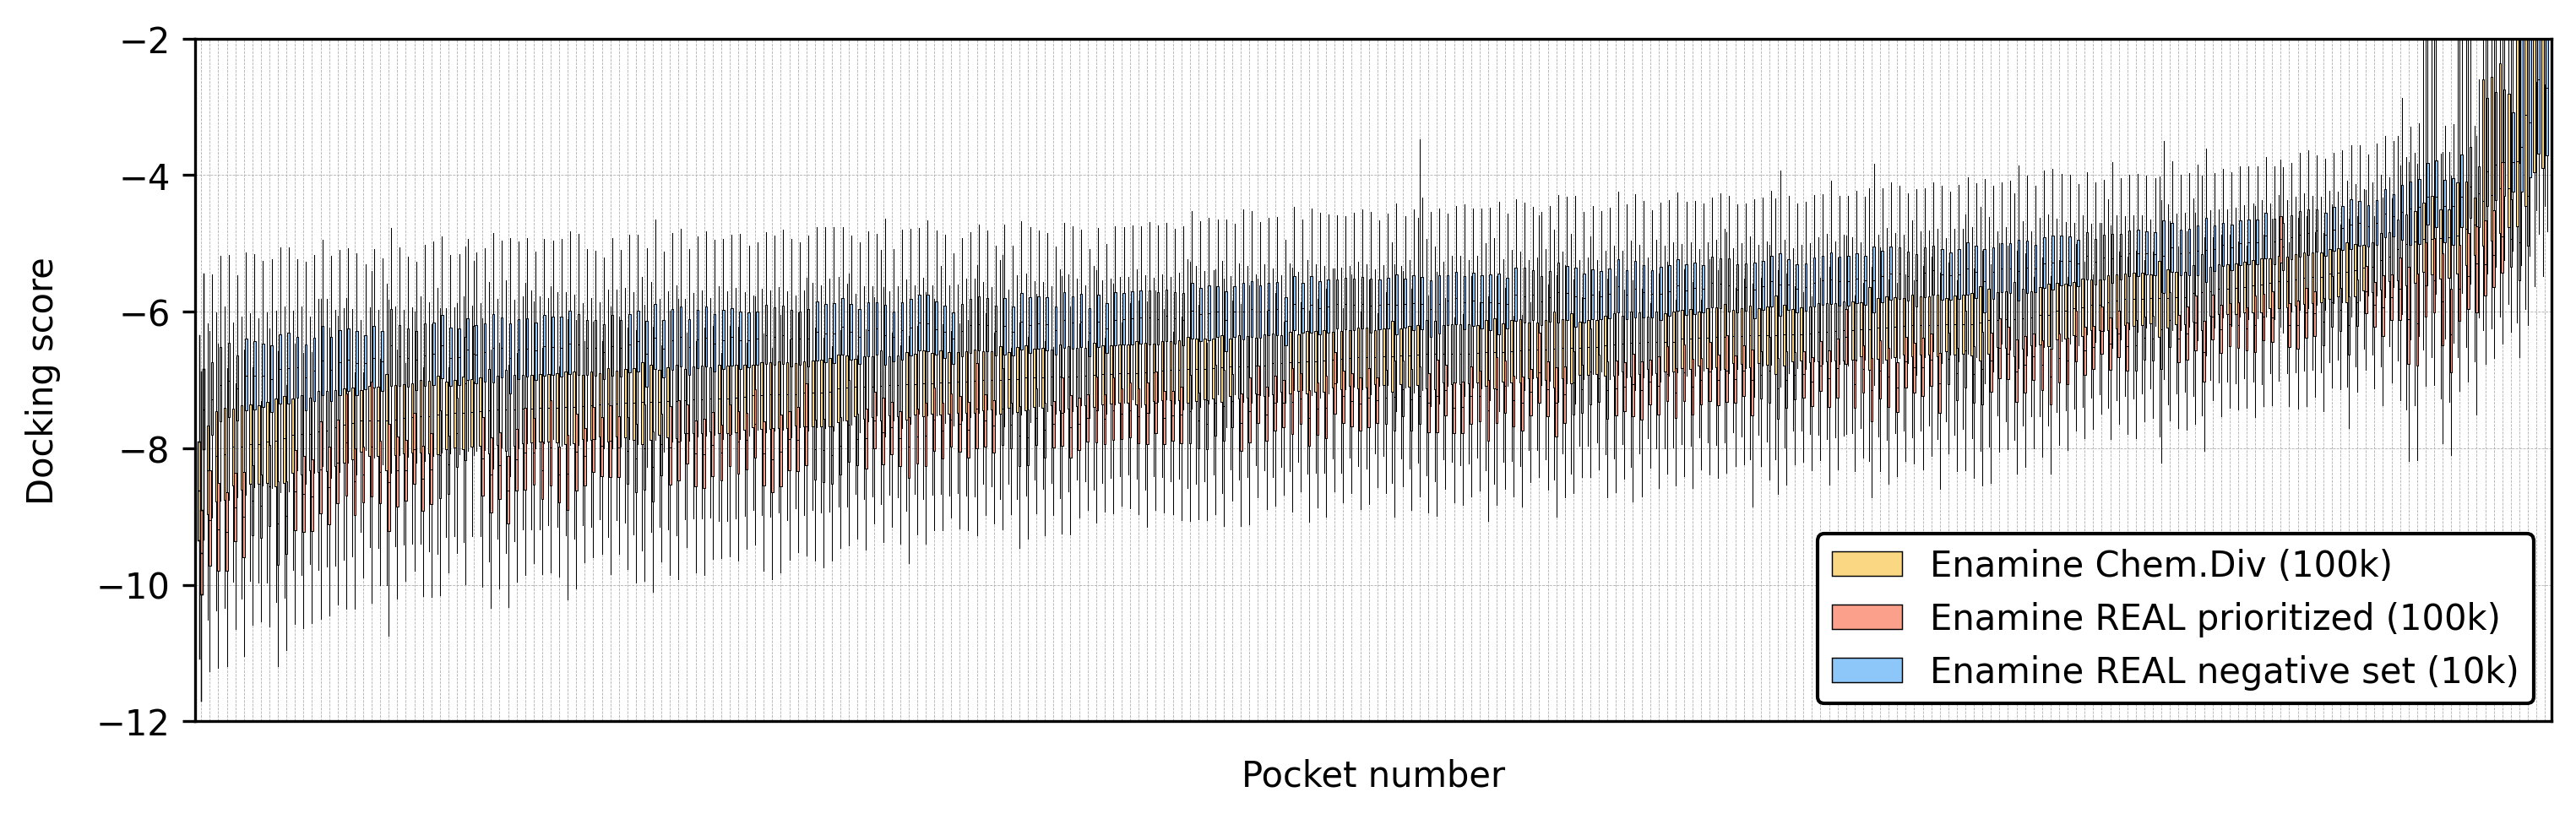

In [54]:
fig, ax = plt.subplots(figsize=(12, 3.5))

for c, pock in enumerate(np.array(sorted(DOCKING_RESULTS_ORIGINAL))[ind]):
    w = 0.25
    if c != 0:
        simple_boxplot(ax, c-w, DOCKING_RESULTS_ORIGINAL[pock].values(), c="#FAD782", width=w)
        simple_boxplot(ax, c, DOCKING_RESULTS_REAL[pock].values(), c="#FAA08B", width=w)
        simple_boxplot(ax, c+w, DOCKING_RESULTS_REAL_BACKGROUND[pock].values(), c="#8DC7FA", width=w)
    else:
        simple_boxplot_label(ax, c-w, DOCKING_RESULTS_ORIGINAL[pock].values(), c="#FAD782", width=w, label=f"Enamine Chem.Div (100k)")
        simple_boxplot_label(ax, c, DOCKING_RESULTS_REAL[pock].values(), c="#FAA08B", width=w, label="Enamine REAL prioritized (100k)")
        simple_boxplot_label(ax, c+w, DOCKING_RESULTS_REAL_BACKGROUND[pock].values(), c="#8DC7FA", width=w, label="Enamine REAL negative set (10k)")

# plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], [pock.replace("_model", "\nmodel") for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], ["" for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("Docking score", labelpad=10)
plt.legend(framealpha=1, edgecolor='k')
plt.ylim([-12, -2])
plt.show()

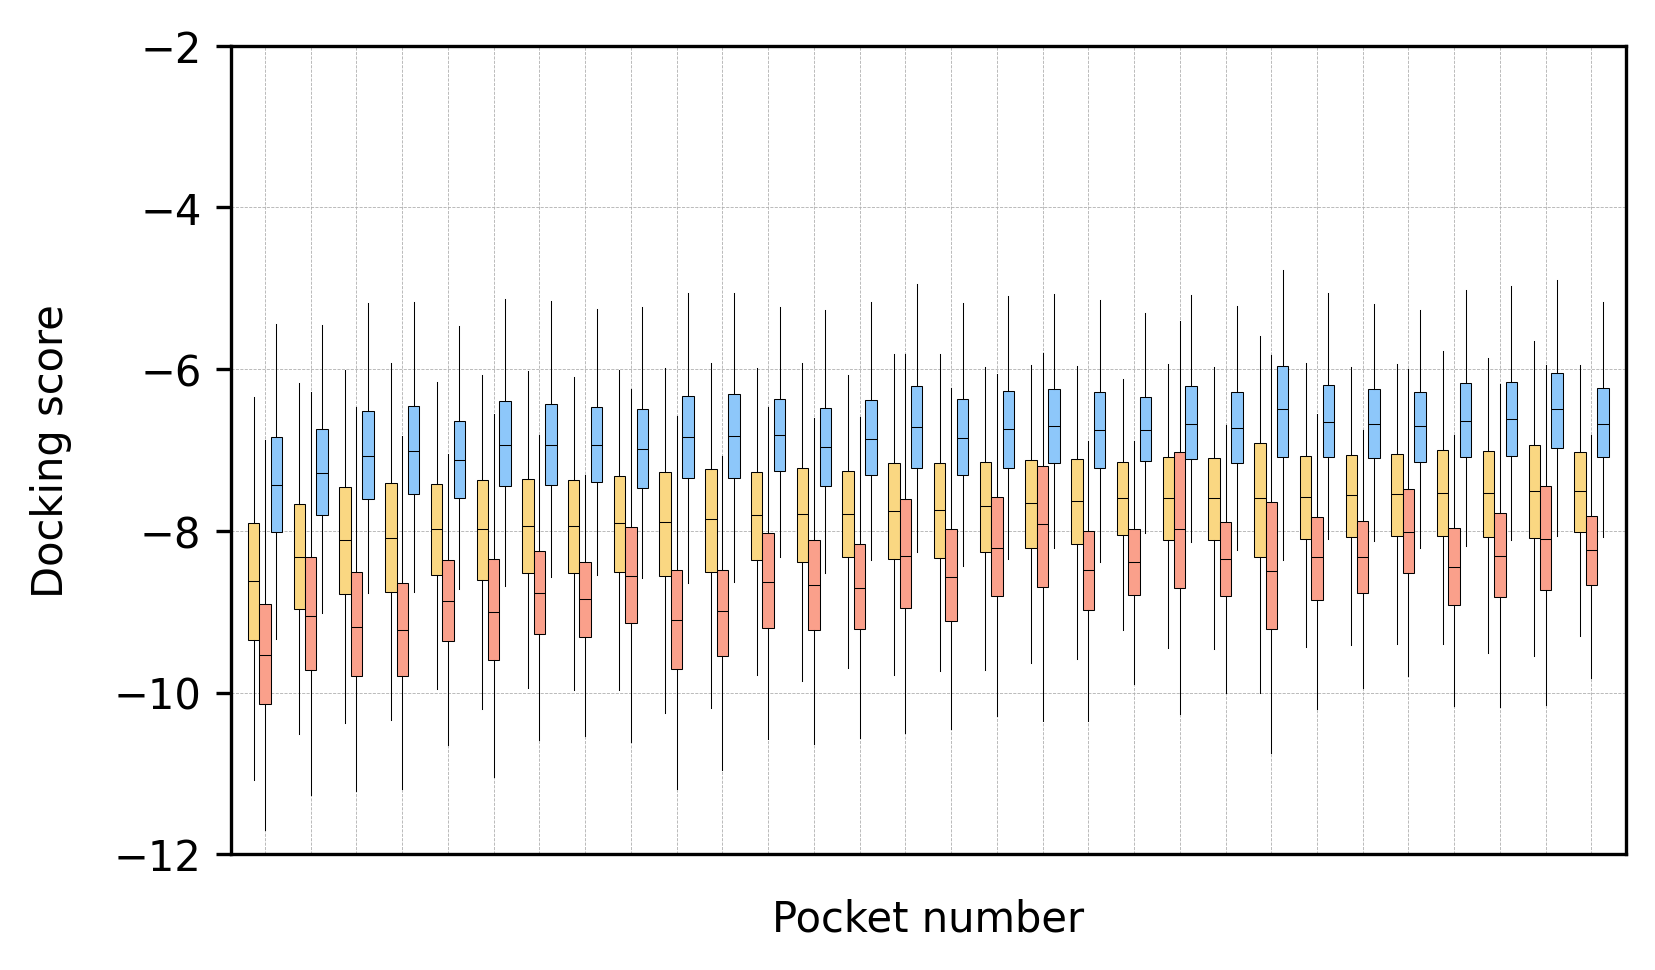

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.5))

for c, pock in enumerate(np.array(sorted(DOCKING_RESULTS_ORIGINAL))[ind][:30]):
    w = 0.25
    simple_boxplot(ax, c-w, DOCKING_RESULTS_ORIGINAL[pock].values(), c="#FAD782", width=w)
    simple_boxplot(ax, c, DOCKING_RESULTS_REAL[pock].values(), c="#FAA08B", width=w)
    simple_boxplot(ax, c+w, DOCKING_RESULTS_REAL_BACKGROUND[pock].values(), c="#8DC7FA", width=w)

# plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], [pock.replace("_model", "\nmodel") for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))][:30], ["" for i in sorted(DOCKING_RESULTS_ORIGINAL)][:30], rotation=30, ha='right', size=7)
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("Docking score", labelpad=10)
# plt.legend(framealpha=1, edgecolor='k')
plt.ylim([-12, -2])
plt.show()

In [10]:
### SEQUENTIAL ANNOTATIONS ###

In [11]:
# Load interpro annotations

pocket_detection_interpro_df = pd.read_csv("../processed/pocket_detection_data_interpro.tsv", sep="\t")

# Add "pocket ID" column
pocket_detection_interpro_df['Pocket ID'] = ["_".join([j.strip(".pdb"),f"pocket_{k}"]) 
                                             for i,j,k in zip(pocket_detection_interpro_df['Uniprot AC'], 
                                             pocket_detection_interpro_df['File name'], 
                                             pocket_detection_interpro_df['Pocket number'])]

# Pocket to interpro
pocket_to_interpro = {}
for pocket in sorted(DOCKING_RESULTS_ORIGINAL):
    annotations = pocket_detection_interpro_df[pocket_detection_interpro_df['Pocket ID'] == pocket]
    annotations = sorted(set(annotations["Interpro curated annotation"].tolist()))
    pocket_to_interpro[pocket] = annotations

In [12]:
Counter(pocket_detection_interpro_df['Interpro curated annotation'])

Counter({'Other too broad/unspecified functional entities': 193,
         'Catalytic Domain (ATP Binding Site)': 175,
         'Anticodon Binding Domain': 91,
         'Editing Domain': 49,
         'tRNA Binding Domain': 17,
         'Other': 9})

In [40]:
ANNOTATIONS = ['Other too broad/unspecified functional entities',
               'Catalytic Domain (ATP Binding Site)',
               'Anticodon Binding Domain',
               'Editing Domain',
               'tRNA Binding Domain']

COLORS = ['#FAD782', '#FAA08B', '#DC9FDC', '#AA96FA','#8DC7FA', '#BEE6B4', '#D2D2D2']
PROTEINS = sorted(set([i for i in pocket_detection_data['Uniprot AC']]))
COLORS_ALL = ["#1f77b4","#aec7e8","#ff7f0e","#ffbb78","#2ca02c","#98df8a","#d62728","#ff9896","#9467bd","#c5b0d5",
          "#8c564b","#c49c94","#e377c2","#f7b6d2","#7f7f7f","#c7c7c7","#bcbd22","#dbdb8d","#17becf","#9edae5","#393b79"]

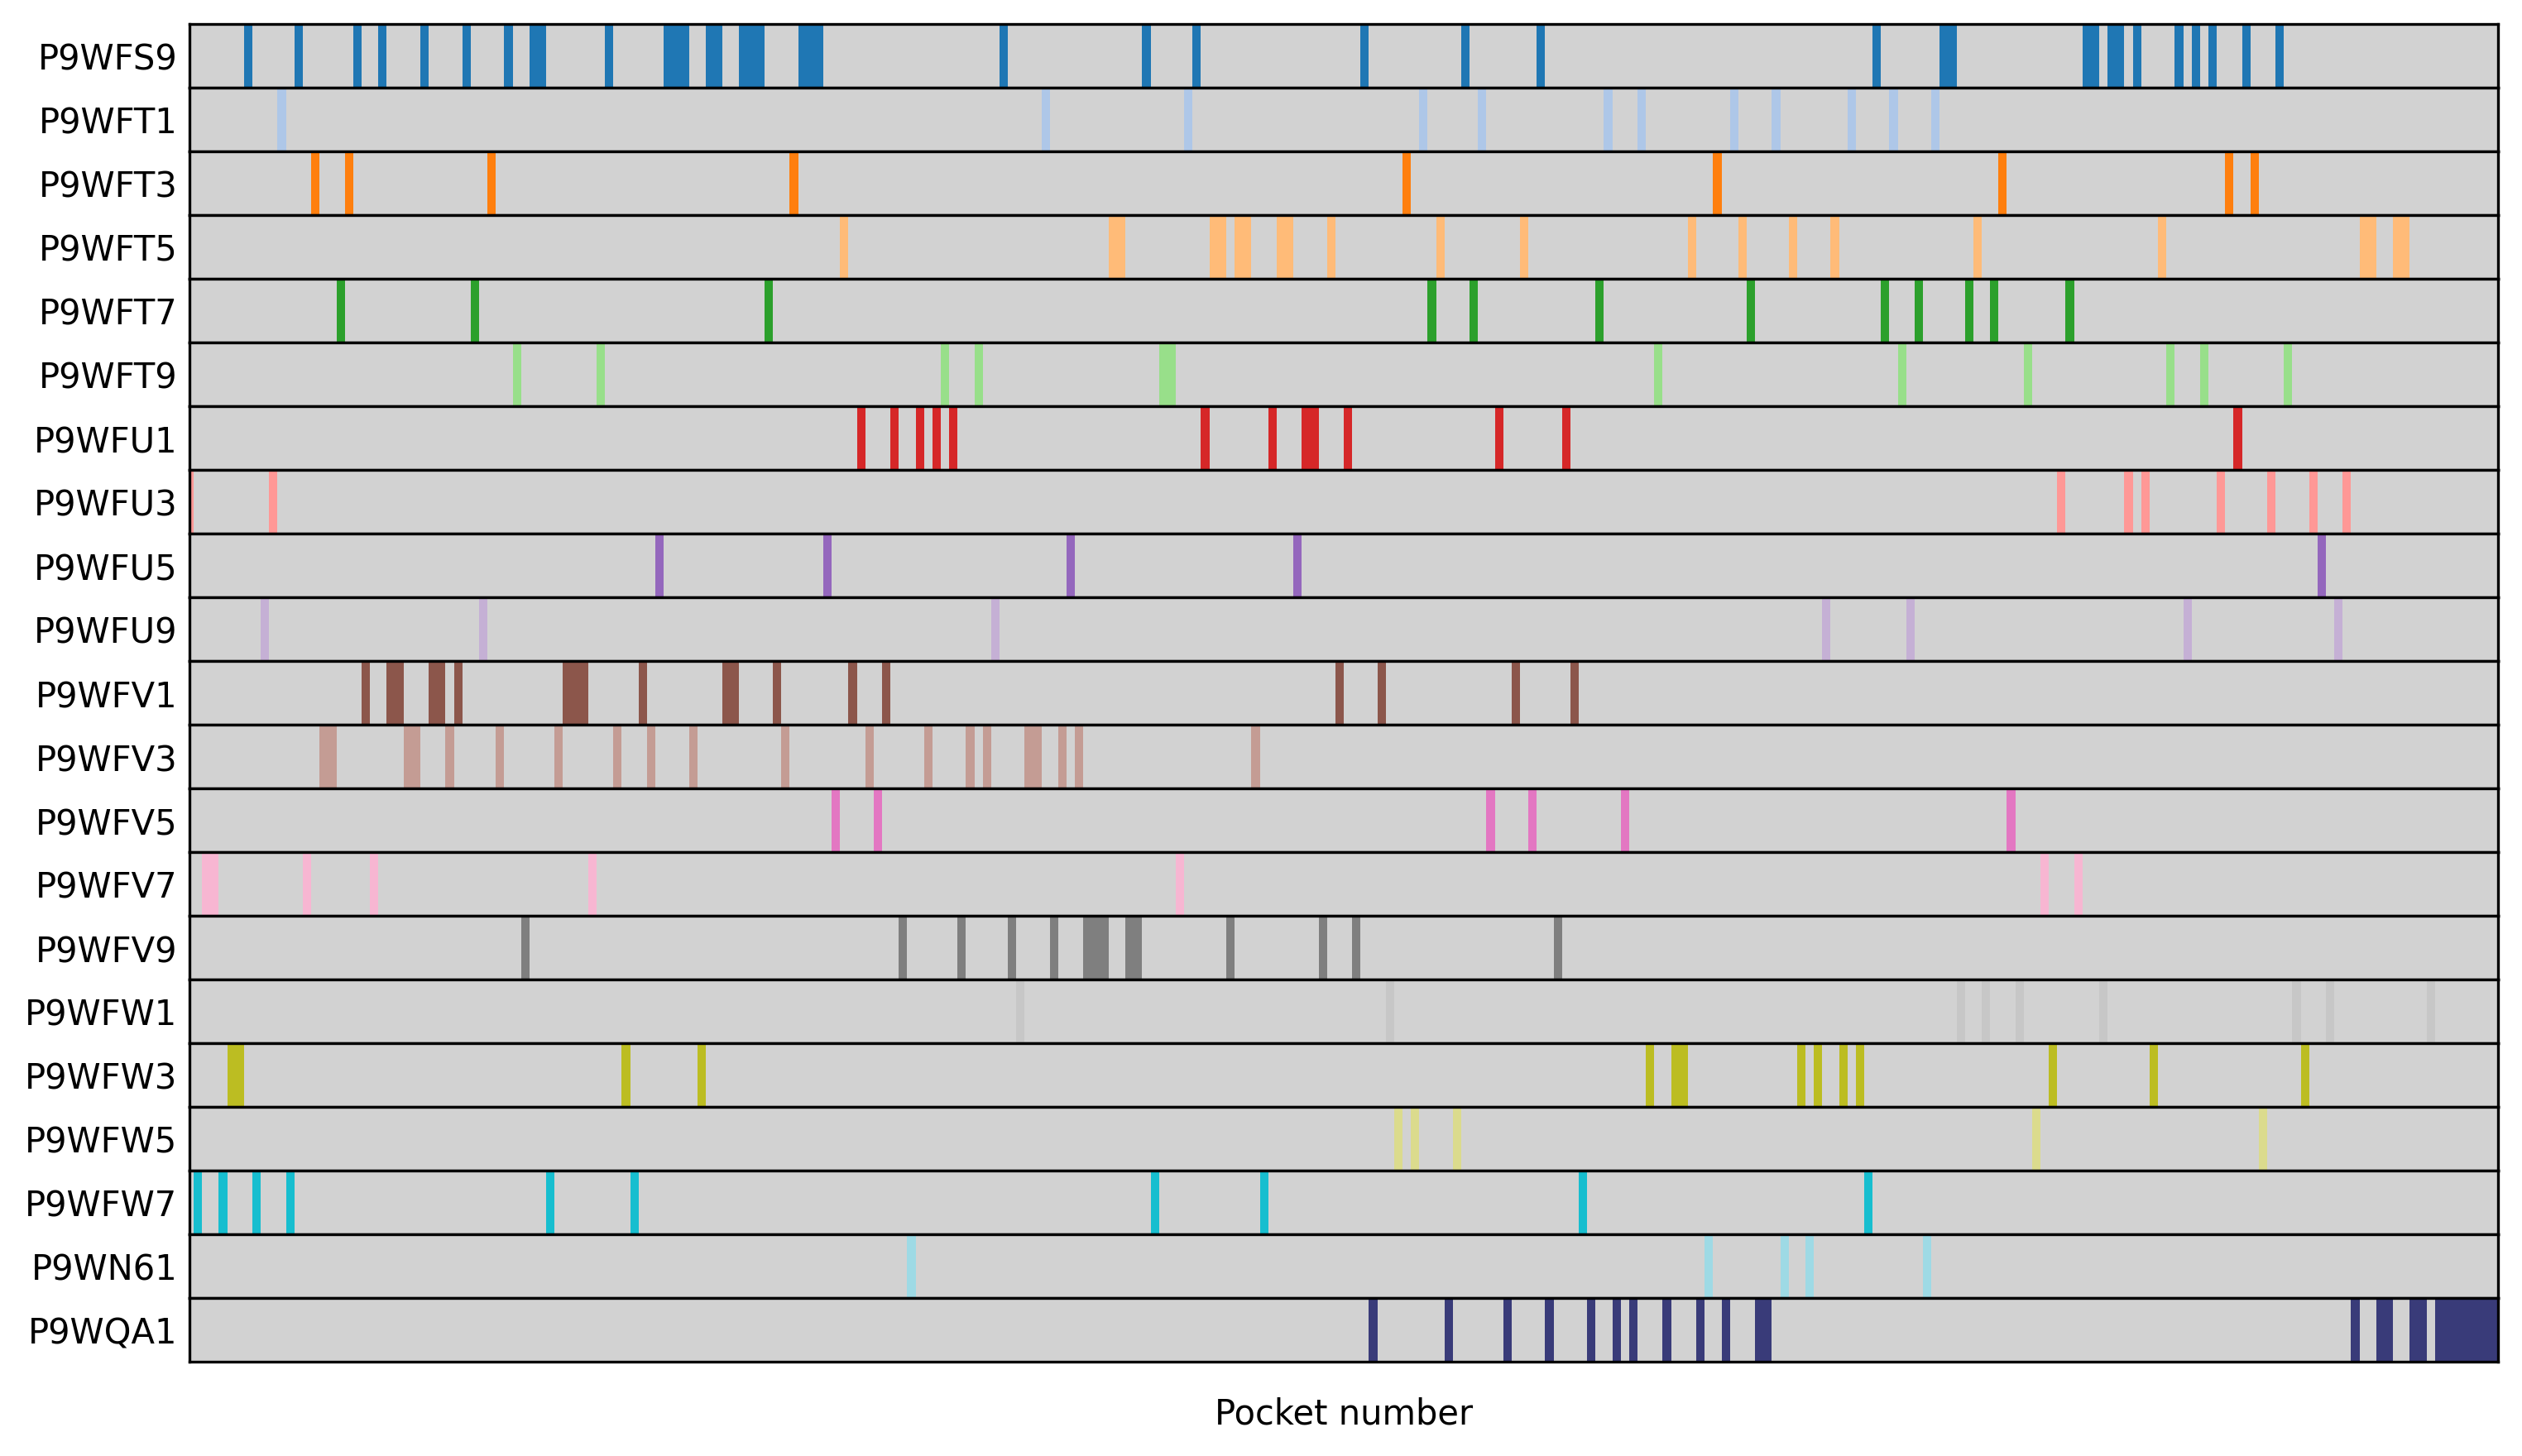

In [50]:
fig, ax = plt.subplots(len(PROTEINS), 1, figsize=(12, 7))
plt.subplots_adjust(hspace=0)

for c, protein in enumerate(PROTEINS):
    
    ax[c].tick_params(axis='both', length=0)
    ax[c].set_xticks([])
    ax[c].set_yticks([0.5], [protein])
    ax[c].set_ylim([0, 1])
    colors = [COLORS_ALL[c] if i.split("_")[1] == protein else COLORS[-1] for i in np.array(sorted(DOCKING_RESULTS_ORIGINAL))[ind]]
    ax[c].bar([i for i in range(len(colors))], [1] * len(colors), color=colors, width=1.0)
    ax[c].set_xlim([0, len(colors) - 1])

ax[-1].set_xlabel("Pocket number", labelpad=10)

# plt.tight_layout()
plt.show()

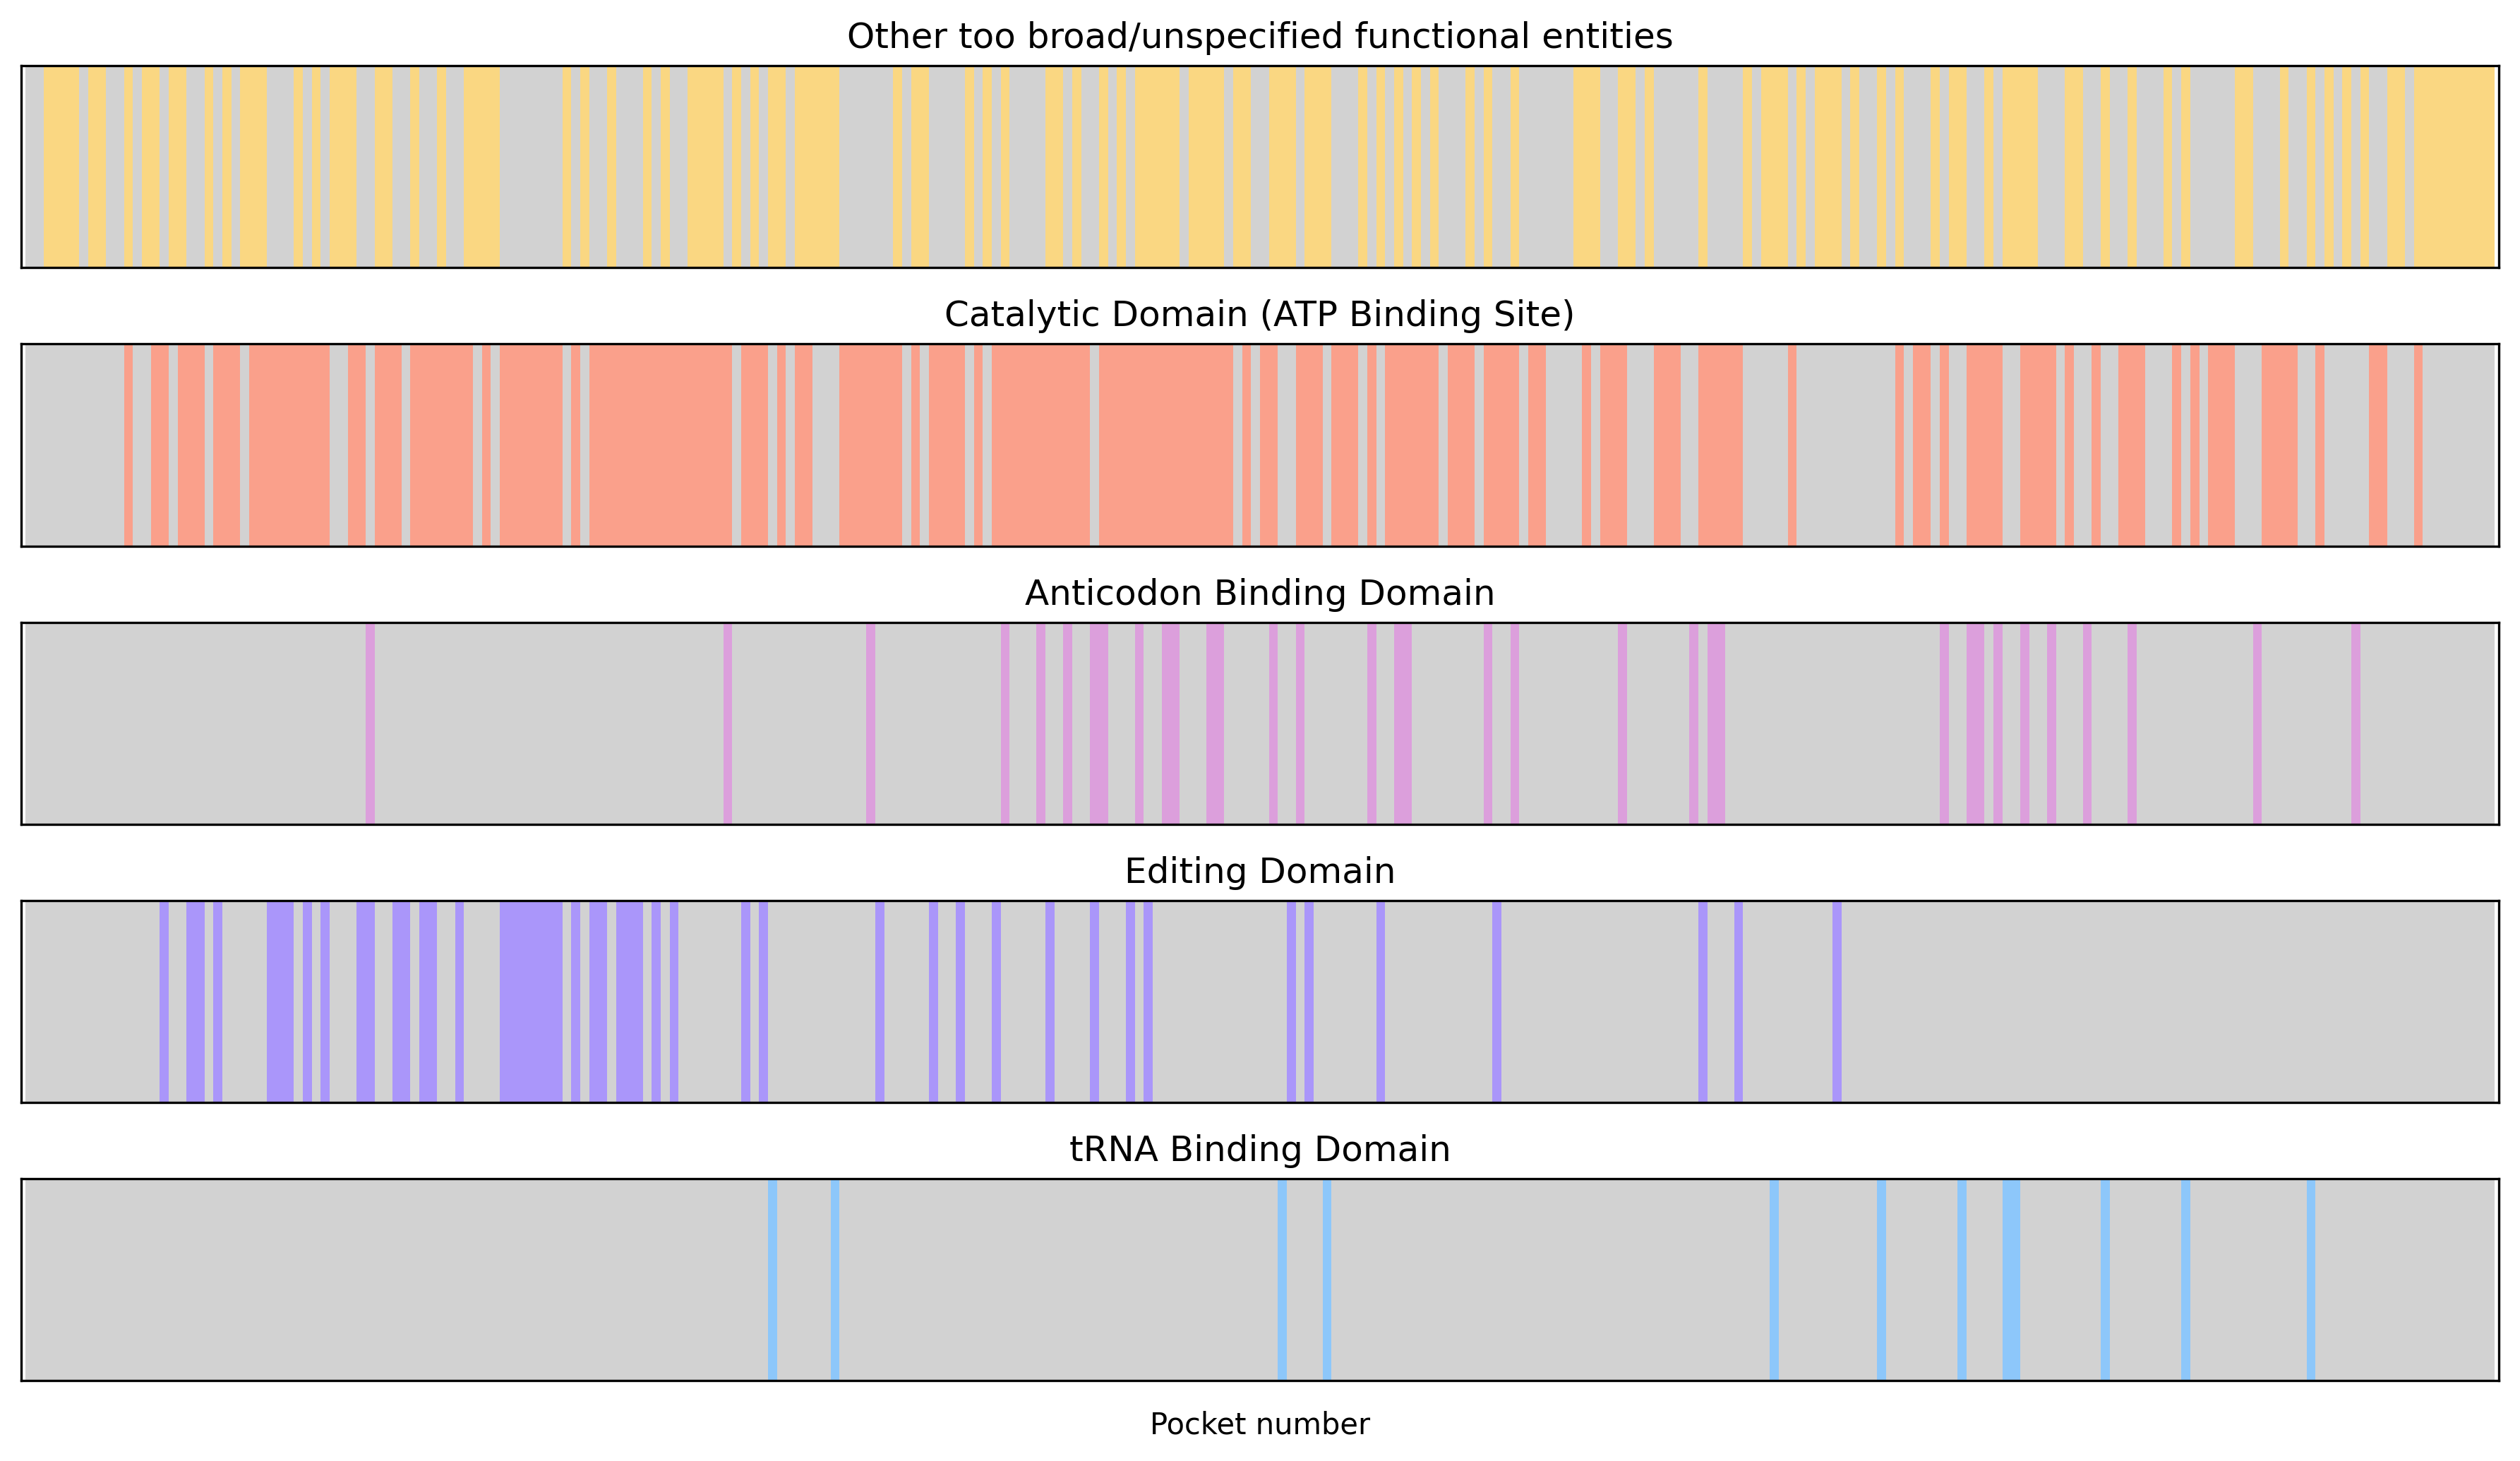

In [51]:
fig, ax = plt.subplots(5, 1, figsize=(12, 7))

for c in range(5):
    
    ax[c].tick_params(axis='both', length=0)
    ax[c].set_xticks([])
    ax[c].set_yticks([])
    ax[c].set_ylim([0, 1])
    ax[c].set_title(ANNOTATIONS[c])
    colors = [COLORS[c] if ANNOTATIONS[c] in pocket_to_interpro[i] else COLORS[-1] for i in np.array(sorted(DOCKING_RESULTS_ORIGINAL))[ind_100]]
    ax[c].bar([i for i in range(len(colors))], [1] * len(colors), color=colors, width=1.0)
    ax[c].set_xlim([-1, len(colors)])

ax[-1].set_xlabel("Pocket number", labelpad=10)
plt.tight_layout()
plt.show()

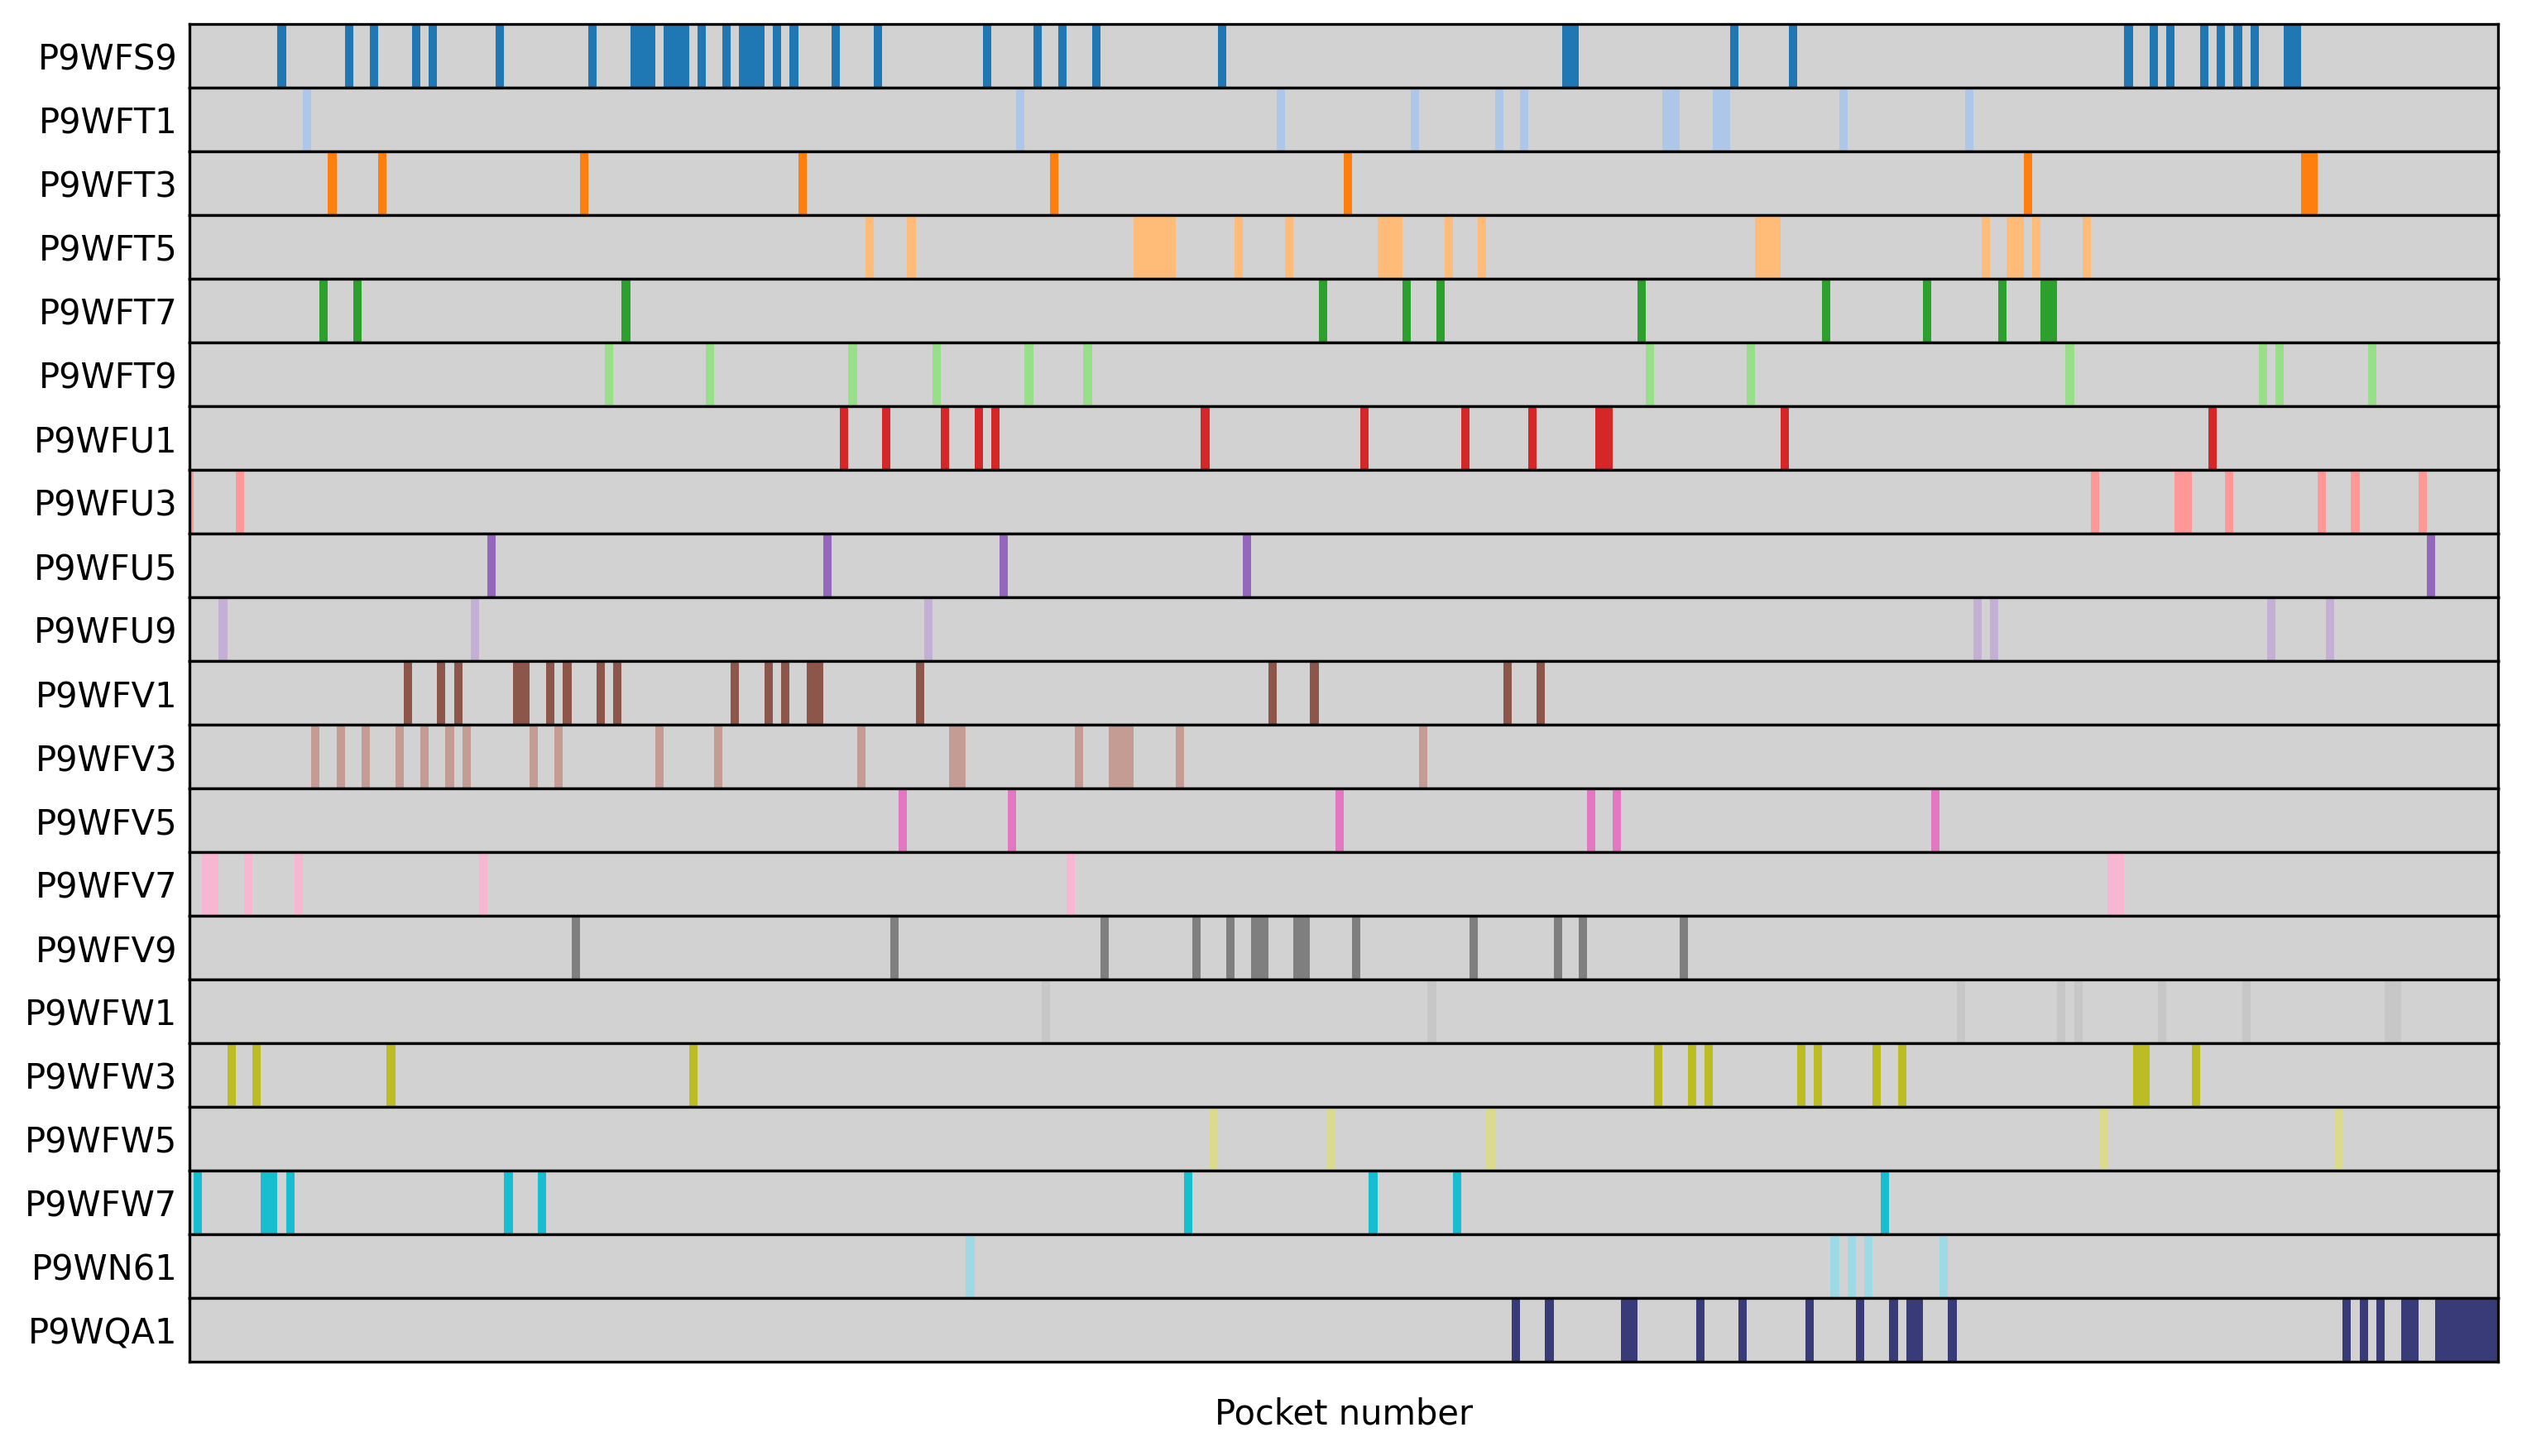

In [52]:
fig, ax = plt.subplots(len(PROTEINS), 1, figsize=(12, 7))
plt.subplots_adjust(hspace=0)

for c, protein in enumerate(PROTEINS):
    
    ax[c].tick_params(axis='both', length=0)
    ax[c].set_xticks([])
    ax[c].set_yticks([0.5], [protein])
    ax[c].set_ylim([0, 1])
    colors = [COLORS_ALL[c] if i.split("_")[1] == protein else COLORS[-1] for i in np.array(sorted(DOCKING_RESULTS_ORIGINAL))[ind_100]]
    ax[c].bar([i for i in range(len(colors))], [1] * len(colors), color=colors, width=1.0)
    ax[c].set_xlim([0, len(colors) - 1])

ax[-1].set_xlabel("Pocket number", labelpad=10)

# plt.tight_layout()
plt.show()

In [11]:
### POLYPHARMACOLOGY STUDIES ###

In [12]:
N = 10_000
ACTIVES = []
proteins = set(pocket_detection_data['Uniprot AC'])
ACTIVES_PER_PROTEIN = {i: set() for i in proteins}
for pocket in tqdm(sorted(DOCKING_RESULTS_REAL)):
    act = sorted(DOCKING_RESULTS_REAL[pocket], key = lambda x: DOCKING_RESULTS_REAL[pocket][x])[:N]
    ACTIVES.extend(act)
    ACTIVES_PER_PROTEIN[pocket.split("_")[1]].update(set(act))


counts = Counter(ACTIVES)
counts_proteins = Counter([cpd for protein in proteins for cpd in ACTIVES_PER_PROTEIN[protein]])
active_10 = [cmpd for cmpd, c in counts.items() if c >= 10]
active_2_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 2]
active_5_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 5]
active_10_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 10]
active_21_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 21]

print(f"TOP-{N} actives")
print(f"Compounds that are active at least once: {len(set(ACTIVES))}")
print(f"Compounds that are active at least 10 times: {len(active_10)}")
print(f"Compounds that are active in at least 2 proteins: {len(active_2_proteins)}")
print(f"Compounds that are active in at least 5 proteins: {len(active_5_proteins)}")
print(f"Compounds that are active in at least 10 proteins: {len(active_10_proteins)}")
print(f"Compounds that are active in at least 21 proteins: {len(active_21_proteins)}")

100%|██████████| 276/276 [00:04<00:00, 65.58it/s]


TOP-10000 actives
Compounds that are active at least once: 620557
Compounds that are active at least 10 times: 68878
Compounds that are active in at least 2 proteins: 327519
Compounds that are active in at least 5 proteins: 116736
Compounds that are active in at least 10 proteins: 34479
Compounds that are active in at least 21 proteins: 398


In [13]:
N = 1_000
ACTIVES = []
proteins = set(pocket_detection_data['Uniprot AC'])
ACTIVES_PER_PROTEIN = {i: set() for i in proteins}
for pocket in tqdm(sorted(DOCKING_RESULTS_REAL)):
    act = sorted(DOCKING_RESULTS_REAL[pocket], key = lambda x: DOCKING_RESULTS_REAL[pocket][x])[:N]
    ACTIVES.extend(act)
    ACTIVES_PER_PROTEIN[pocket.split("_")[1]].update(set(act))


counts = Counter(ACTIVES)
counts_proteins = Counter([cpd for protein in proteins for cpd in ACTIVES_PER_PROTEIN[protein]])
active_10 = [cmpd for cmpd, c in counts.items() if c >= 10]
active_2_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 2]
active_5_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 5]
active_10_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 10]
active_21_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 21]

print(f"TOP-{N} actives")
print(f"Compounds that are active at least once: {len(set(ACTIVES))}")
print(f"Compounds that are active at least 10 times: {len(active_10)}")
print(f"Compounds that are active in at least 2 proteins: {len(active_2_proteins)}")
print(f"Compounds that are active in at least 5 proteins: {len(active_5_proteins)}")
print(f"Compounds that are active in at least 10 proteins: {len(active_10_proteins)}")
print(f"Compounds that are active in at least 21 proteins: {len(active_21_proteins)}")

100%|██████████| 276/276 [00:03<00:00, 69.58it/s]


TOP-1000 actives
Compounds that are active at least once: 113375
Compounds that are active at least 10 times: 4158
Compounds that are active in at least 2 proteins: 37799
Compounds that are active in at least 5 proteins: 8290
Compounds that are active in at least 10 proteins: 1821
Compounds that are active in at least 21 proteins: 13


In [14]:
N = 100
ACTIVES = []
proteins = set(pocket_detection_data['Uniprot AC'])
ACTIVES_PER_PROTEIN = {i: set() for i in proteins}
for pocket in tqdm(sorted(DOCKING_RESULTS_REAL)):
    act = sorted(DOCKING_RESULTS_REAL[pocket], key = lambda x: DOCKING_RESULTS_REAL[pocket][x])[:N]
    ACTIVES.extend(act)
    ACTIVES_PER_PROTEIN[pocket.split("_")[1]].update(set(act))


counts = Counter(ACTIVES)
counts_proteins = Counter([cpd for protein in proteins for cpd in ACTIVES_PER_PROTEIN[protein]])
active_10 = [cmpd for cmpd, c in counts.items() if c >= 10]
active_2_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 2]
active_5_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 5]
active_10_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 10]
active_21_proteins = [cmpd for cmpd, c in counts_proteins.items() if c >= 21]

print(f"TOP-{N} actives")
print(f"Compounds that are active at least once: {len(set(ACTIVES))}")
print(f"Compounds that are active at least 10 times: {len(active_10)}")
print(f"Compounds that are active in at least 2 proteins: {len(active_2_proteins)}")
print(f"Compounds that are active in at least 5 proteins: {len(active_5_proteins)}")
print(f"Compounds that are active in at least 10 proteins: {len(active_10_proteins)}")
print(f"Compounds that are active in at least 21 proteins: {len(active_21_proteins)}")

100%|██████████| 276/276 [00:03<00:00, 71.83it/s]

TOP-100 actives
Compounds that are active at least once: 15885
Compounds that are active at least 10 times: 223
Compounds that are active in at least 2 proteins: 3557
Compounds that are active in at least 5 proteins: 551
Compounds that are active in at least 10 proteins: 89
Compounds that are active in at least 21 proteins: 0
